In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys
import warnings

In [3]:
from src import test, train
import src.experiment as experiment

In [4]:
warnings.filterwarnings("ignore")

In [5]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [6]:
metrics

{'loss': np.float32(-64889.348),
 'loss_batch_mean': np.float32(-506.94803),
 'log_w': np.float32(56778.18),
 'log_w_batch_mean': np.float32(443.57953)}

In [7]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

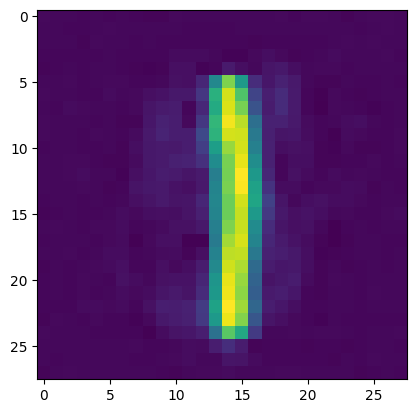

In [8]:
plt.imshow(recons[0].squeeze())

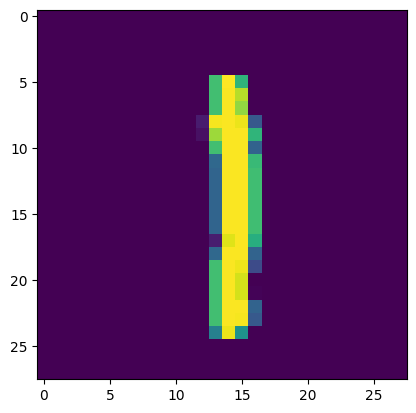

In [9]:
plt.imshow(data[0].squeeze())

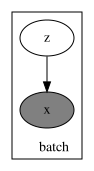

In [10]:
objects['monad'].render_model()

In [11]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [12]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [13]:
portion_zeros(zs)

Array(0.91963774, dtype=float32)

In [14]:
r2(xs, xs_hat)

Array(0.9021155, dtype=float32)

In [15]:
xs.shape

(9984, 1, 28, 28)

In [16]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=omniglot", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [17]:
metrics

{'loss': np.float32(-28053.87),
 'loss_batch_mean': np.float32(-219.17085),
 'log_w': np.float32(24547.137),
 'log_w_batch_mean': np.float32(191.7745)}

In [18]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

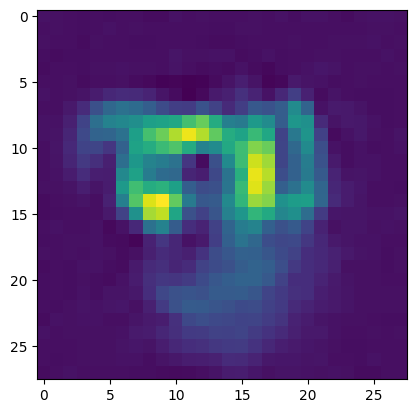

In [19]:
plt.imshow(recons[0].squeeze())

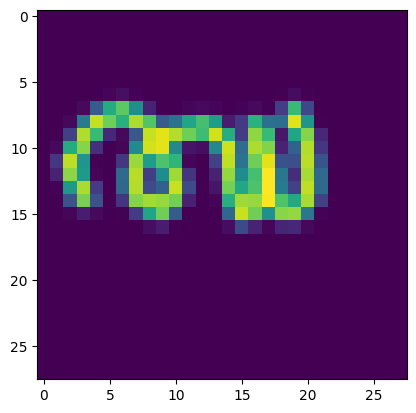

In [20]:
plt.imshow(data[0].squeeze())

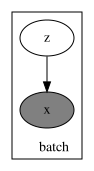

In [21]:
objects['monad'].render_model()

In [22]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [23]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [24]:
portion_zeros(zs)

Array(0.93019414, dtype=float32)

In [25]:
r2(xs, xs_hat)

Array(0.6239183, dtype=float32)

In [26]:
xs.shape

(13056, 1, 28, 28)

In [27]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], ckpt_path="logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                      t_total=100)

15it [07:48, 31.25s/it]


In [28]:
metrics

{'du_norm': Array([44.6537   , 21.503983 , 16.540854 , 15.006489 , 14.659145 ,
        14.60746  , 14.6189165, 14.670883 , 14.733395 , 14.774027 ,
        14.788997 , 14.792678 , 14.796108 , 14.8018875, 14.808913 ,
        14.815962 , 14.822278 , 14.827465 , 14.831439 , 14.834355 ,
        14.836433 , 14.837882 , 14.838893 , 14.839607 , 14.840116 ,
        14.840492 , 14.840786 , 14.841064 , 14.841396 , 14.841775 ,
        14.842201 , 14.84265  , 14.843082 , 14.843499 , 14.843891 ,
        14.844247 , 14.84458  , 14.8448925, 14.845177 , 14.845432 ,
        14.845677 , 14.845891 , 14.84607  , 14.846221 , 14.846339 ,
        14.8464155, 14.846462 , 14.846495 , 14.846506 , 14.84651  ,
        14.846522 , 14.846533 , 14.846541 , 14.846551 , 14.846553 ,
        14.846556 , 14.8465605, 14.846563 , 14.846566 , 14.846568 ,
        14.846574 , 14.846583 , 14.846597 , 14.846606 , 14.846619 ,
        14.84663  , 14.846643 , 14.8466625, 14.84668  , 14.84669  ,
        14.846699 , 14.846713 , 14.84

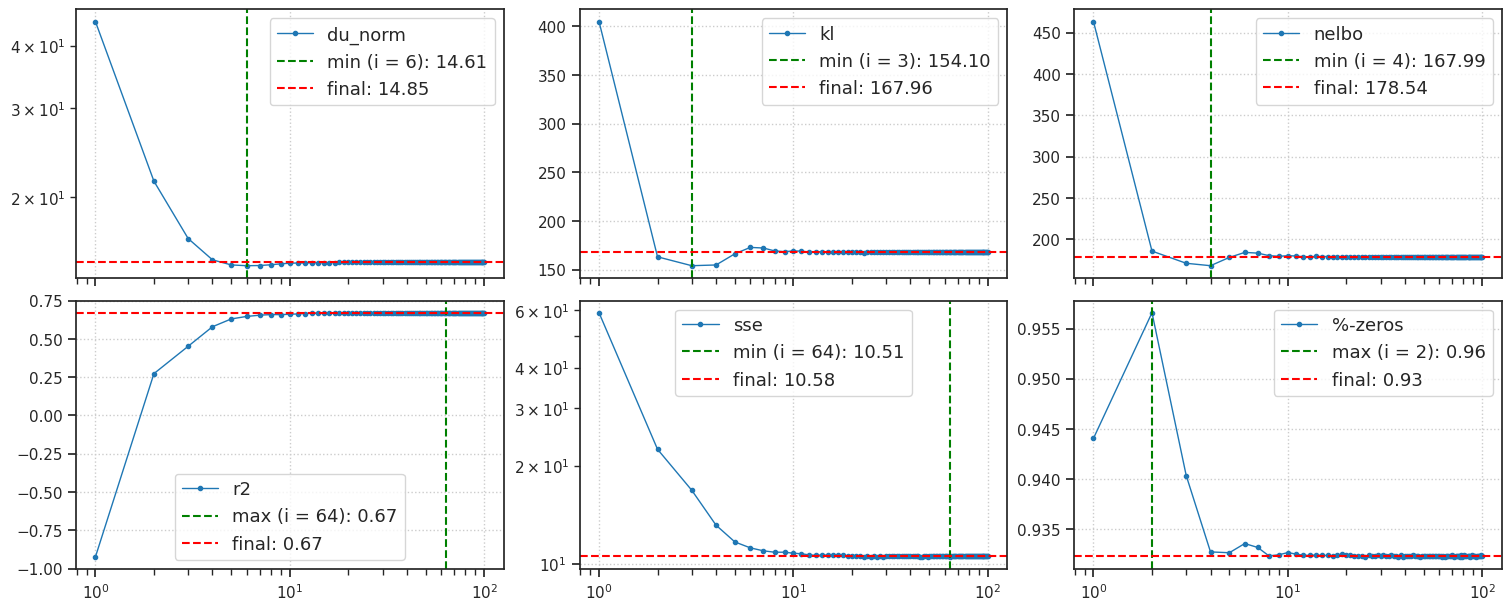

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [29]:
experiment.plot_convergence(metrics)

In [30]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=emnist", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [31]:
metrics

{'loss': np.float32(141022.47),
 'loss_batch_mean': np.float32(1101.738),
 'log_w': np.float32(-123394.66),
 'log_w_batch_mean': np.float32(-964.02075)}

In [32]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

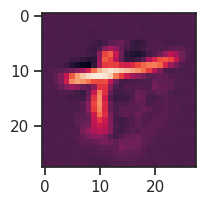

In [33]:
plt.imshow(recons[0].squeeze())

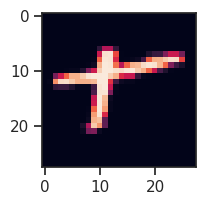

In [34]:
plt.imshow(data[0].squeeze())

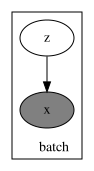

In [35]:
objects['monad'].render_model()

In [36]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [37]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [38]:
portion_zeros(zs)

Array(0.9150123, dtype=float32)

In [39]:
r2(xs, xs_hat)

Array(0.5275527, dtype=float32)

In [40]:
xs.shape

(18688, 1, 28, 28)

In [41]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], ckpt_path="logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                      t_total=100)

88it [47:47, 32.59s/it]


In [42]:
metrics

{'du_norm': Array([44.846714, 22.3994  , 18.570164, 17.989906, 18.159275, 18.333609,
        18.42328 , 18.467394, 18.492254, 18.50614 , 18.51314 , 18.516792,
        18.519243, 18.521278, 18.523058, 18.524519, 18.52562 , 18.526379,
        18.526863, 18.527187, 18.527386, 18.527536, 18.52764 , 18.527704,
        18.52774 , 18.527752, 18.527754, 18.52775 , 18.52775 , 18.52775 ,
        18.527754, 18.527765, 18.527777, 18.52779 , 18.527805, 18.527815,
        18.527824, 18.527832, 18.527836, 18.527838, 18.527843, 18.52785 ,
        18.52785 , 18.527853, 18.527851, 18.527855, 18.527851, 18.527851,
        18.527855, 18.527855, 18.527855, 18.527855, 18.527853, 18.527859,
        18.52785 , 18.527851, 18.52785 , 18.527851, 18.527851, 18.527855,
        18.527855, 18.527855, 18.527853, 18.527851, 18.527847, 18.527855,
        18.527851, 18.527851, 18.527847, 18.527851, 18.527851, 18.527845,
        18.527851, 18.527855, 18.527853, 18.527851, 18.527855, 18.527847,
        18.527851, 18.52785

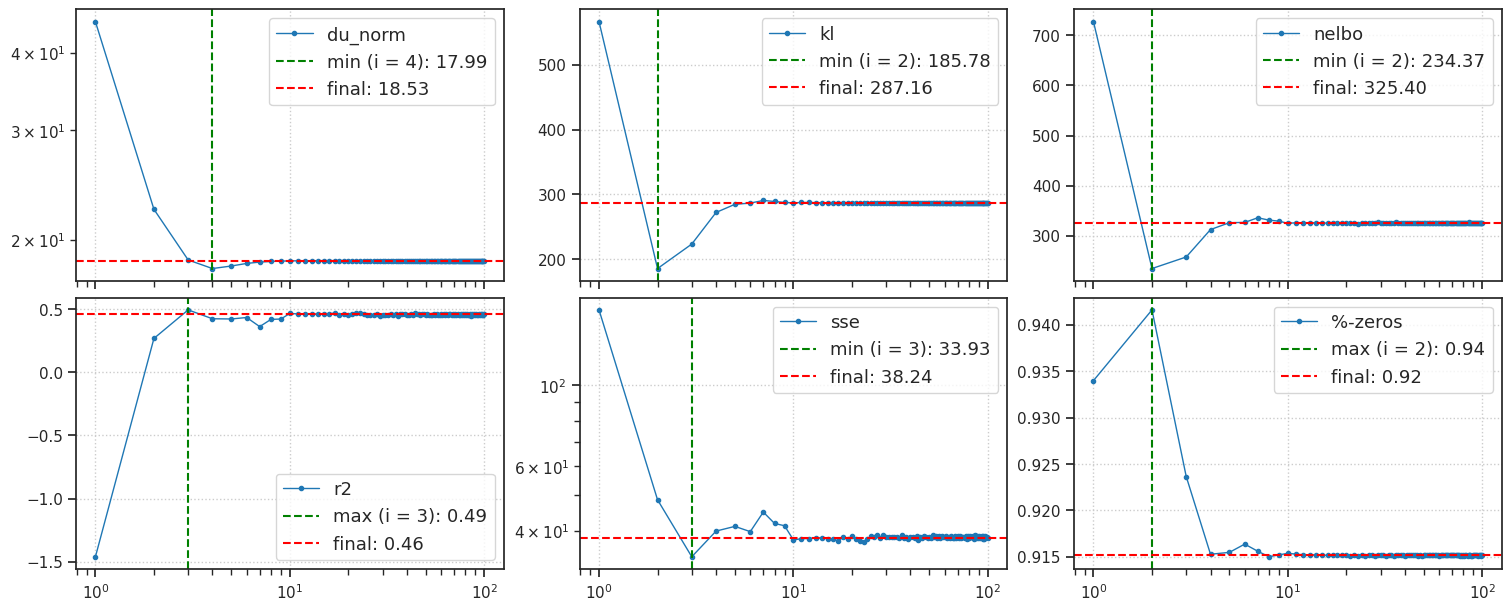

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [43]:
experiment.plot_convergence(metrics)